In [1]:
import sys
import os

# Get the absolute path to the 'python' directory (one level up from 'notebooks')
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)


In [6]:
from Utils.FilePaths import *
import pandas as pd
import matplotlib as plt

data_folder = COPERNICUS

In [9]:
## Load files
files = list(Path.glob(data_folder, '*.csv'))
files

[PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Copernicus/Sentinel-5P NO2-NO2_large-area.csv'),
 PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Copernicus/Sentinel-5P SO2-SO2_large-area.csv'),
 PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Copernicus/Sentinel-5P NO2-NO2_small-area.csv'),
 PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/Copernicus/Sentinel-5P SO2-SO2_small-area.csv')]

In [11]:
## Load O2-NO2_small-area.csv
df_no2 = pd.read_csv(files[2], index_col=0)
df_no2.index = pd.to_datetime(df_no2.index, format="%m-%d-%y")
df_no2.head(5)

,C0/min,C0/max,C0/mean,C0/stDev,C0/sampleCount,C0/noDataCount,C0/median,C0/p10,C0/p90
C0/date,,,,,,,,,
2018-05-02,0.000052,0.000148,0.000088,0.000024,150,0,0.000084,0.000065,0.000142
2018-05-03,0.000029,0.000066,0.000048,0.000013,150,115,0.000057,0.000029,0.000066
2018-05-04,0.000084,0.000542,0.000282,0.000123,150,0,0.000268,0.000151,0.000453
2018-05-05,0.000019,0.000091,0.000054,0.000017,150,0,0.000053,0.000032,0.000076
2018-05-06,0.000019,0.000062,0.000036,0.000013,150,0,0.000033,0.000020,0.000057


In [18]:
# Flag and down-weight unreliable days
df_no2["valid_frac"] = 1 - df_no2["C0/noDataCount"] / df_no2["C0/sampleCount"]
df_no2.head()

,C0/min,C0/max,C0/mean,C0/stDev,C0/sampleCount,C0/noDataCount,C0/median,C0/p10,C0/p90,valid_frac
C0/date,,,,,,,,,,
2018-05-02,0.000052,0.000148,0.000088,0.000024,150,0,0.000084,0.000065,0.000142,1.000000
2018-05-03,0.000029,0.000066,0.000048,0.000013,150,115,0.000057,0.000029,0.000066,0.233333
2018-05-04,0.000084,0.000542,0.000282,0.000123,150,0,0.000268,0.000151,0.000453,1.000000
2018-05-05,0.000019,0.000091,0.000054,0.000017,150,0,0.000053,0.000032,0.000076,1.000000
2018-05-06,0.000019,0.000062,0.000036,0.000013,150,0,0.000033,0.000020,0.000057,1.000000


In [ ]:
print("All: ", len(df_no2.query('valid_frac > 0')))
print("Valid fraction: ", len(df_no2.query('valid_frac > 0.5')))

All:  1543
Valid fraction:  938


<Axes: title={'center': 'NO2 measurements for Hamburg-City'}, xlabel='C0/date'>

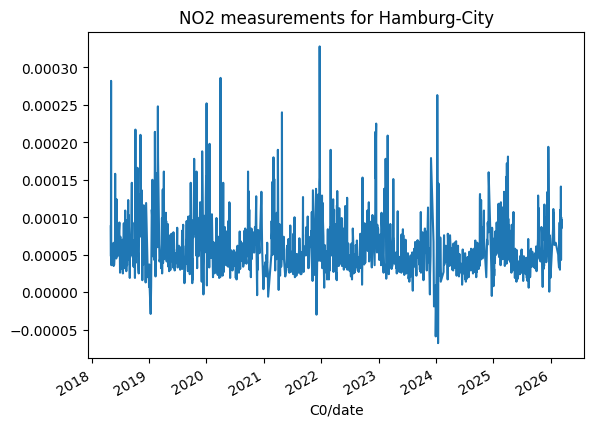

In [11]:
df_no2["C0/mean"].plot(kind="line", title="NO2 measurements for Hamburg-City")

In [ ]:
import numpy as np
from pmdarima import auto_arima

s_log = np.log(s_monthly_clean)   # log-transform


# Drop or interpolate rows below a threshold (e.g. <30% valid pixels)
df_clean = df_no2[df_no2["valid_frac"] > 0.3]["C0/mean"]
df_clean = df_clean.resample("D").mean().interpolate(method="time")

# Only use months where >50% of days had valid retrievals
df_monthly_valid = df_no2[df_no2["valid_frac"] > 0.3]["C0/mean"] \
                     .resample("ME").mean() \
                     .dropna()
s_log = np.log(df_monthly_valid * 1e4)
model_log = auto_arima(
    s_log,
    seasonal=True, m=12,
    d=None, D=None,
    information_criterion='aic',
    stepwise=True,
    trace=True
)

# Back-transform forecasts
fc_log = model_log.predict(n_periods=12, return_conf_int=True)
fc_mean   = np.exp(fc_log[0])
fc_ci     = np.exp(fc_log[1])  # exp preserves interval direction

print(model_log.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=47.962, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=37.575, Time=0.05 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=41.429, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=184.543, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=35.656, Time=0.01 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=37.608, Time=0.02 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=35.130, Time=0.01 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=36.617, Time=0.07 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=36.820, Time=0.03 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(3,0,0)(0,0,0)[12] intercept   : AIC=36.944, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=37.044, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=35.981, Time

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
s_monthly_clean.head()

C0/date
2018-05-31    0.667500
2018-06-30    0.643750
2018-07-31    0.531538
2018-08-31    0.639474
2018-09-30    0.645556
Freq: ME, Name: C0/mean, dtype: float64

In [36]:
fc_log[0]

2026-04-30   -0.447091
2026-05-31   -0.467959
2026-06-30   -0.507314
2026-07-31   -0.523011
2026-08-31   -0.534281
2026-09-30   -0.540346
2026-10-31   -0.544065
2026-11-30   -0.546209
2026-12-31   -0.547482
2027-01-31   -0.548226
2027-02-28   -0.548665
2027-03-31   -0.548922
Freq: ME, dtype: float64

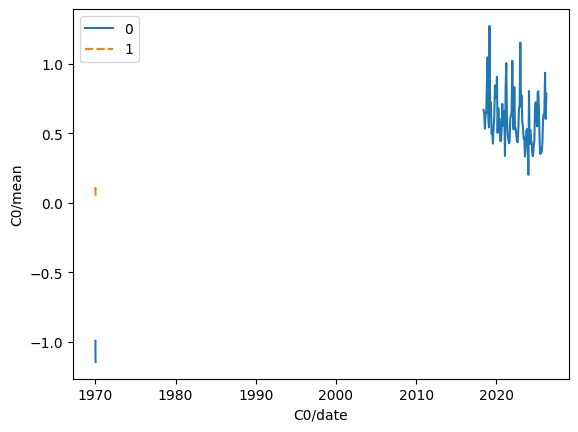

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax0 = plt.subplots()
sns.lineplot(data=s_monthly_clean, ax=ax0)
sns.lineplot(data=fc_log[], ax=ax0)
plt.show()



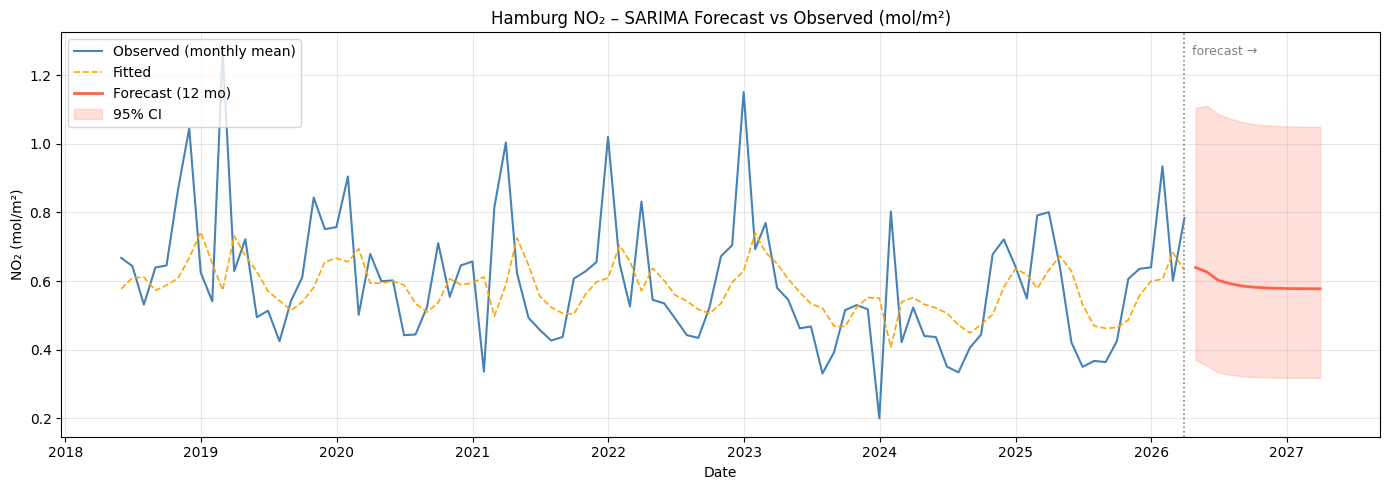

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Unpack forecast ────────────────────────────────────────────────────────
fc_values = np.exp(fc_log[0])          # back-transform point forecast
fc_lower  = np.exp(fc_log[1][:, 0])   # lower 95% CI
fc_upper  = np.exp(fc_log[1][:, 1])   # upper 95% CI

# ── Build a date index for the forecast period ─────────────────────────────
last_date  = s_monthly_clean.index[-1]
fc_index   = pd.date_range(last_date, periods=13, freq="ME")[1:]  # 12 months ahead

fc_series  = pd.Series(fc_values, index=fc_index)
fc_low_s   = pd.Series(fc_lower,  index=fc_index)
fc_high_s  = pd.Series(fc_upper,  index=fc_index)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Historical — show last 3 years for clarity
history = s_monthly_clean.loc["2023":]
ax.plot(s_monthly_clean.index, s_monthly_clean.values,
        color="steelblue", linewidth=1.5, label="Observed (monthly mean)")

# Fitted values on the log model
fitted = np.exp(model_log.predict_in_sample())
ax.plot(s_monthly_clean.index, fitted,
        color="orange", linewidth=1.2, linestyle="--", label="Fitted")

# Forecast + CI
ax.plot(fc_series.index, fc_series.values,
        color="tomato", linewidth=2, label="Forecast (12 mo)")
ax.fill_between(fc_index, fc_low_s, fc_high_s,
                color="tomato", alpha=0.2, label="95% CI")

# Vertical line at forecast start
ax.axvline(last_date, color="gray", linestyle=":", linewidth=1.2)
ax.text(last_date, ax.get_ylim()[1]*0.95, "  forecast →",
        color="gray", fontsize=9)

ax.set_title("Hamburg NO₂ – SARIMA Forecast vs Observed (mol/m²)")
ax.set_xlabel("Date")
ax.set_ylabel("NO₂ (mol/m²)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [48]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5, test_size=12)  # 12-month test windows
maes = []
for train_idx, test_idx in tscv.split(s_monthly_clean):
    train, test = s_monthly_clean.iloc[train_idx], s_monthly_clean.iloc[test_idx]
    m = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,12)).fit(disp=False)
    pred = m.forecast(len(test))
    maes.append(mean_absolute_error(test, pred))
print(f"CV MAE: {np.mean(maes):.5f} ± {np.std(maes):.5f}")


CV MAE: 0.13404 ± 0.02438
